# What a program-only agent can establish about an unknown environment

Companion notebook to our ARC Prize 2026 Paper Track writeup.

It runs offline. The simulation comparison below is **computed live** when you run
this notebook; the figures measured against recorded real games are shipped as a
small JSON, because those traces are 2.8&nbsp;GB and Kaggle notebooks have no network.

Every number here traces back to a document in the repository that records the run
which produced it — including the numbers that contradict our earlier claims.

## Setup

The `arcagi3` library is pure Python and needs only `numpy`, which Kaggle already has.
Attach the repository as a dataset, or run this notebook from inside a clone.

In [1]:
import json
import pathlib
import sys

# Find the library whether this runs from a clone or from an attached dataset.
CANDIDATES = [
    pathlib.Path("agi3"),
    pathlib.Path("../agi3"),
    *pathlib.Path("/kaggle/input").glob("*/agi3"),
    *pathlib.Path("/kaggle/input").glob("*/*/agi3"),
]
for path in CANDIDATES:
    if (path / "arcagi3").is_dir():
        sys.path.insert(0, str(path))
        print(f"library: {path.resolve()}")
        break
else:
    raise SystemExit("could not find agi3/ — attach the repository as a dataset")

DATA = next(
    (p for p in [pathlib.Path("paper/data"), pathlib.Path("../paper/data"),
                 *pathlib.Path("/kaggle/input").glob("*/paper/data"),
                 *pathlib.Path("/kaggle/input").glob("*/*/paper/data")]
     if p.is_dir()),
    None,
)
print(f"measured results: {DATA}")

library: /home/user/arc-prize-2026/agi3
measured results: ../paper/data


## 1. Simulation does not predict reality

Two arenas, the same policies. One is the quiet environment we wrote first; the
other carries noise measured from recorded games — a HUD strip that advances on
every action, sprites that change shape as they move, and as a consequence a board
that changes on essentially every action.

This cell computes the table rather than printing a stored one.

In [2]:
from arcagi3.agent import GreedyAgent, RandomAgent
from arcagi3.budget import run_episode
from arcagi3.explorer import ExplorerAgent
from arcagi3.mock import MockEnvironment
from arcagi3.navigator_v1 import NavigatorAgent
from arcagi3.noisy_mock import NoisyEnvironment

POLICIES = {
    "random": lambda: RandomAgent(seed=0),
    "greedy": GreedyAgent,
    "explorer": ExplorerAgent,
    "navigator": NavigatorAgent,
}
ARENAS = {"quiet mock": MockEnvironment, "noise-calibrated": NoisyEnvironment}

print(f"{'policy':<11}{'learns?':>9}" + "".join(f"{name:>20}" for name in ARENAS))
print("-" * 60)
for name, make_policy in POLICIES.items():
    learns = "no" if name in ("random", "greedy") else "yes"
    cells = []
    for make_arena in ARENAS.values():
        r = run_episode(make_policy(), make_arena(), max_actions=400)
        cells.append(f"{'WIN' if r.won else 'lost'} {r.levels_completed}/{r.total_levels}")
    print(f"{name:<11}{learns:>9}" + "".join(f"{c:>20}" for c in cells))

policy       learns?          quiet mock    noise-calibrated
------------------------------------------------------------


random            no            lost 2/3            lost 2/3
greedy            no             WIN 3/3             WIN 3/3
explorer         yes             WIN 3/3            lost 0/3
navigator        yes             WIN 3/3            lost 0/3


Three things follow.

The noise destroys **only the methods that learn**. The random and hard-coded
policies score identically in both arenas, because neither holds a model for the
noise to corrupt.

On a board carrying the noise real boards carry, **random play beats both of our
deliberate policies**, two levels to none.

And results in the quiet arena carry **no information** about the noisy one: three
policies clear every level there, and their fates then diverge completely.

## 2. What probing costs, measured on real boards

These come from replaying 500 recorded runs — 25 official games, 20 passes each —
and checking the mapping the learner recovers against the action labels the
recordings carry.

In [3]:
measured = json.loads((DATA / "control-learning-measured.json").read_text())
curve = measured["learning_curve"]

print(measured["_provenance"]["source"])
print()
print(f"{'observations':>13}{'mappings':>10}{'correct':>9}{'accuracy':>10}")
print("-" * 42)
for row in curve:
    print(f"{row['observations']:>13}{row['mappings']:>10}{row['correct']:>9}"
          f"{row['accuracy']:>9.0%}")

500 traces (25 games x 20 passes) from Tufalabs/duck-harness example-run

 observations  mappings  correct  accuracy
------------------------------------------
            5         0        0       0%
           10       391      218      56%
           20       779      497      64%
           40       902      653      72%
           80       718      578      81%
          160       188      149      79%


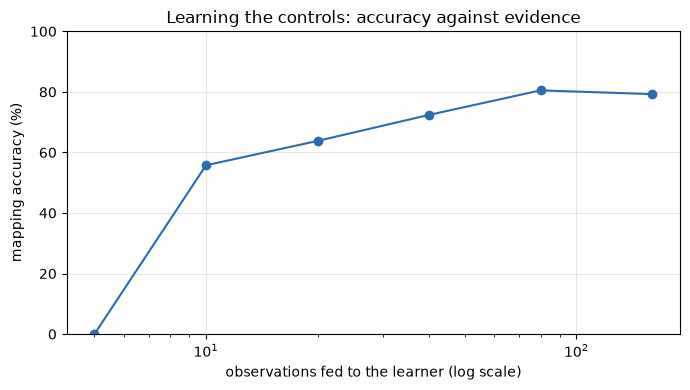

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([r["observations"] for r in curve], [r["accuracy"] * 100 for r in curve],
        marker="o", color="#2b6cb0")
ax.set_xscale("log")
ax.set_xlabel("observations fed to the learner (log scale)")
ax.set_ylabel("mapping accuracy (%)")
ax.set_title("Learning the controls: accuracy against evidence")
ax.grid(alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

Nothing is learnable below about ten observations, accuracy climbs to roughly 80%
by eighty, and then flattens.

A separate measurement matters more in play: a mapping *correct about two
directions* costs a median of **12 observations**. Those answer different
questions, and conflating them — as we did — makes starting look far more
expensive than it is. Two correct directions are enough to begin.

## 3. Is the learner's confidence honest?

It reports a confidence alongside each mapping. If that number means anything,
accuracy should rise with it.

    confidence  mappings  correct  accuracy
-------------------------------------------
       0.2-0.4         8        0       0%
       0.4-0.6       225       80      36%
       0.6-0.8       388      327      84%
       0.8-1.0       451      383      85%


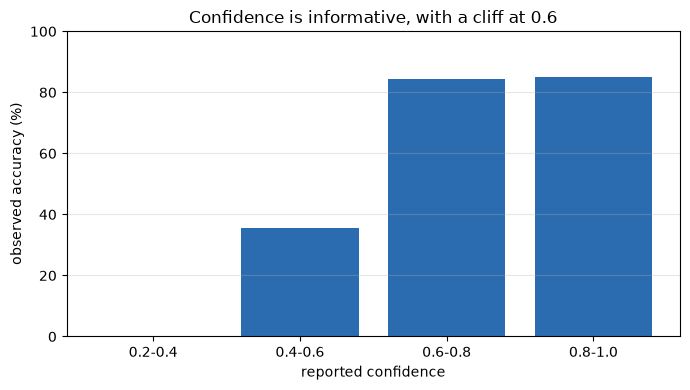

In [5]:
bands = measured["confidence_calibration"]
print(f"{'confidence':>14}{'mappings':>10}{'correct':>9}{'accuracy':>10}")
print("-" * 43)
for row in bands:
    label = f"{row['confidence_from']:.1f}-{row['confidence_to']:.1f}"
    print(f"{label:>14}{row['mappings']:>10}{row['correct']:>9}{row['accuracy']:>9.0%}")

fig, ax = plt.subplots(figsize=(7, 4))
labels = [f"{r['confidence_from']:.1f}-{r['confidence_to']:.1f}" for r in bands]
ax.bar(labels, [r["accuracy"] * 100 for r in bands], color="#2b6cb0")
ax.set_xlabel("reported confidence")
ax.set_ylabel("observed accuracy (%)")
ax.set_title("Confidence is informative, with a cliff at 0.6")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

There is a sharp threshold at **0.6**: below it the mapping is 36% accurate, above
it 84–85%. Waiting for higher confidence buys no further accuracy while costing
actions.

It is informative but not a guarantee — even the top band is wrong 15% of the time.

## 4. Four times the simulator convinced us

| # | Looked settled | Then failed | Mechanism |
|---|---|---|---|
| 1 | object matching, 88% in our mock | **0.4%** on 2,276 real transitions | an animating sprite does not match itself between frames |
| 2 | "the board changed" as a click signal | **worthless** — 91–100% of real clicks change the board | a signal present almost always separates nothing |
| 3 | our best walking policy, 3/3 levels | **0/3** once the board is noisy | the centre of mass is dragged sideways by animation |
| 4 | cell alignment, 3/3 on the *calibrated* mock | **55%** on real boards, against the centroid's 79% | alignment discards an observation whenever nothing lines up |

The fourth is the one that matters most. The arena it passed was itself calibrated
from statistics measured over 500 real runs, and it still selected the worse design.
Matching measured statistics is not sufficient, because the statistics one chooses
to match come from the same understanding that shaped the method being tested.

We later recovered 22 of those 24 points by falling back to the centre of mass when
alignment finds nothing — so the failure was real, but its cause was discarded
evidence rather than a conflict of principle.

## 5. Which noise actually matters

Switching each property on and off separately, against our own walking game:

| noise applied | policy result |
|---|---|
| animating the controlled object only | **clears 0 of 3 levels** |
| animating every small object | clears 3 of 3 |
| animating only the goal | clears 3 of 3 |
| HUD alone, nothing animated | clears 3 of 3 |
| controlled object animated, no HUD | **clears 0 of 3** |

More noise made the test **easier**. It is not noise that defeats learning, but
noise on the signal being learned from — which is a statement about learning
agents rather than about ARC.

## 6. Three checks

These would have caught all four of our failures, and they need no ARC-specific
knowledge:

1. **Test against data you did not generate.** Recordings, traces, a live game.
2. **Measure the base rate of whatever signal you learn from.** A signal present
   95% of the time separates nothing, however reasonable it looks.
3. **Measure component accuracy and playing ability separately.** Ours diverged
   completely: 79% mapping accuracy, zero levels cleared.

The noise itself is packaged as a wrapper that takes any environment returning
`FrameData`, so the same check runs against another team's agent unchanged:

```python
from arcagi3.noise import NoiseWrapper
noisy = NoiseWrapper(YourEnvironment(), sprite_colour=<the object you steer>)
```

Naming the object under control is what makes it a hard test — the table in
section 5 is why.

In [6]:
# The wrapper takes an environment it has never seen.
from arcagi3.click_mock import ClickEnvironment
from arcagi3.noise import NoiseWrapper

frame = NoiseWrapper(ClickEnvironment()).reset()
print(f"wrapped a different game: board is {len(frame.frame[-1])}x{len(frame.frame[-1][0])}")

wrapped a different game: board is 11x10


## Reproducing all of it

```bash
git clone https://github.com/Panus15/arc-prize-2026
cd arc-prize-2026/agi3 && ./setup.sh
.venv/bin/pytest                                      # 196 tests
PYTHONPATH=. .venv/bin/python scripts/simulation_gap.py   # the table in section 1
PYTHONPATH=. .venv/bin/python scripts/validate_control.py # sections 2 and 3
```

The repository is MIT-0. Each figure above has a document in `docs/` recording the
run behind it.